# 05 — Métricas y Evaluación del Modelo BERT

1. Predicciones sobre el test set
2. Classification report completo (precision / recall / F1 por clase)
3. Matriz de confusión
4. Comparación BERT vs XGBoost (baseline)
5. Análisis de errores — ejemplos mal clasificados

**Prerequisito:** haber ejecutado `04_entrenamiento.ipynb`

In [ ]:
import os
import sys
from pathlib import Path

# Fix conflicto OpenMP en Windows (debe ir antes de import torch)
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# torch y transformers primero para evitar conflictos de DLL con matplotlib/mlflow
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer

import joblib
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score,
)

ROOT = Path().resolve().parents[3]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

PIPELINE_DIR = ROOT / 'src/classifier/bert_pipeline'
MODEL_DIR    = PIPELINE_DIR / 'models'
BERT_PATH    = MODEL_DIR / 'bert_model'
LABELS       = ['inaceptable', 'alto_riesgo', 'riesgo_limitado', 'riesgo_minimo']
COLORS       = ['#c0392b', '#e67e22', '#f1c40f', '#27ae60']

print('OK')

## 1. Cargar modelo y test set

In [12]:
if not BERT_PATH.exists():
    raise FileNotFoundError(f'Modelo no encontrado en {BERT_PATH}. Ejecuta 04_entrenamiento.ipynb primero.')

le      = joblib.load(MODEL_DIR / 'label_encoder.joblib')
df_test = joblib.load(MODEL_DIR / 'test_split.joblib')

tokenizer = AutoTokenizer.from_pretrained(str(BERT_PATH))
model     = AutoModelForSequenceClassification.from_pretrained(str(BERT_PATH))
model.eval()

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device)

print(f'Device : {device}')
print(f'Test   : {len(df_test)} ejemplos')

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1279.33it/s, Materializing param=classifier.weight]                                      


Device : cuda
Test   : 400 ejemplos


## 2. Inferencia sobre el test set

In [13]:
from tqdm.auto import tqdm

y_true  = df_test['label'].tolist()
y_pred  = []
y_proba = []

for text in tqdm(df_test['descripcion'].tolist(), desc='Prediciendo'):
    inputs = tokenizer(text, truncation=True, max_length=256, return_tensors='pt').to(device)
    with torch.no_grad():
        logits = model(**inputs).logits
    proba = torch.softmax(logits, dim=-1)[0].tolist()
    y_pred.append(int(logits.argmax(-1).item()))
    y_proba.append(proba)

print(f'Predicciones completadas: {len(y_pred)}')

Prediciendo: 100%|██████████| 400/400 [00:02<00:00, 152.05it/s]

Predicciones completadas: 400


## 3. Classification Report

In [14]:
target_names = le.classes_.tolist()
report = classification_report(y_true, y_pred, target_names=target_names)
f1_macro = f1_score(y_true, y_pred, average='macro')
acc      = accuracy_score(y_true, y_pred)

print('=== Classification Report — BERT ===' )
print(report)
print(f'F1 Macro : {f1_macro:.4f}')
print(f'Accuracy : {acc:.4f}')

=== Classification Report — BERT ===
                 precision    recall  f1-score   support

    alto_riesgo       0.70      0.70      0.70       101
    inaceptable       0.76      0.67      0.71        98
riesgo_limitado       0.63      0.81      0.71       102
  riesgo_minimo       0.93      0.75      0.83        99

       accuracy                           0.73       400
      macro avg       0.75      0.73      0.74       400
   weighted avg       0.75      0.73      0.74       400

F1 Macro : 0.7382
Accuracy : 0.7350


## 4. F1 por clase

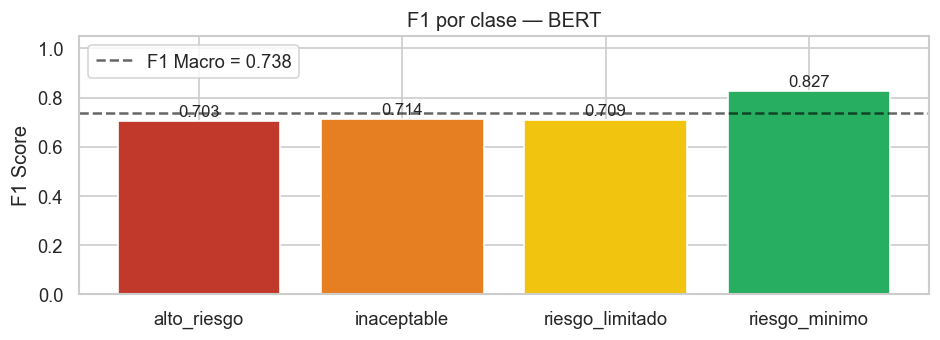

In [15]:
from sklearn.metrics import f1_score as f1
f1_per_class = f1(y_true, y_pred, average=None, labels=list(range(len(LABELS))))

fig, ax = plt.subplots(figsize=(8, 3))
bars = ax.bar(target_names, f1_per_class, color=COLORS)
ax.axhline(f1_macro, color='black', linestyle='--', alpha=0.6, label=f'F1 Macro = {f1_macro:.3f}')
ax.set_ylim(0, 1.05)
ax.set_ylabel('F1 Score')
ax.set_title('F1 por clase — BERT')
ax.legend()
for bar, val in zip(bars, f1_per_class):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig(MODEL_DIR / 'f1_per_class_bert.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Matriz de confusión

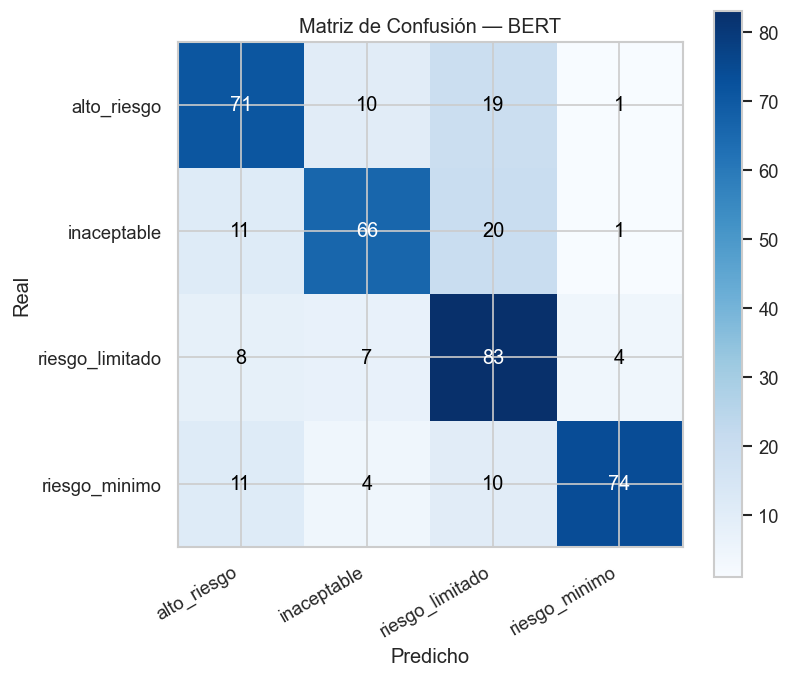

In [16]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar(im, ax=ax)
ax.set(
    xticks=np.arange(len(target_names)),
    yticks=np.arange(len(target_names)),
    xticklabels=target_names,
    yticklabels=target_names,
    xlabel='Predicho',
    ylabel='Real',
    title='Matriz de Confusión — BERT',
)
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
for i in range(len(target_names)):
    for j in range(len(target_names)):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=12)
fig.tight_layout()
fig.savefig(MODEL_DIR / 'confusion_matrix_bert.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Comparación BERT vs XGBoost (baseline)

Cargamos el clasificador XGBoost existente y comparamos sobre el mismo test set.

In [ ]:
XGB_F1_MACRO = 0.8822  # valor registrado en MLflow del experimento XGBoost+SVD

# Intentar inferencia con el modelo XGBoost actual sobre el mismo test set
try:
    from src.classifier.main import predict_risk
    xgb_preds_labels = [predict_risk(t)['risk_level'] for t in df_test['descripcion'].tolist()]
    label2id = {lbl: i for i, lbl in enumerate(LABELS)}
    xgb_preds = [label2id.get(p, 0) for p in xgb_preds_labels]
    xgb_f1 = f1_score(y_true, xgb_preds, average='macro')
    print(f'XGBoost F1 Macro (inferencia en vivo): {xgb_f1:.4f}')
    xgb_label = f'XGBoost (test set actual)\nF1={xgb_f1:.3f}'
except Exception as e:
    xgb_f1 = XGB_F1_MACRO
    xgb_label = f'XGBoost (MLflow registrado)\nF1={xgb_f1:.3f}'
    print(f'XGBoost no disponible en vivo ({e}), usando valor registrado: {xgb_f1}')

# Gráfico comparativo
fig, ax = plt.subplots(figsize=(6, 4))
models  = ['XGBoost\n(baseline)', 'BERT\n(este experimento)']
f1s     = [xgb_f1, f1_macro]
colors  = ['#7f8c8d', '#2980b9']
bars    = ax.bar(models, f1s, color=colors, width=0.4)
ax.set_ylim(0, 1.05)
ax.set_ylabel('F1 Macro')
ax.set_title('Comparación de modelos — mismo test set')
for bar, val in zip(bars, f1s):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.4f}', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(MODEL_DIR / 'comparacion_modelos.png', dpi=120, bbox_inches='tight')
plt.show()

mejora = (f1_macro - xgb_f1) / xgb_f1 * 100
print(f'\nMejora relativa BERT vs XGBoost: {mejora:+.1f}%')
if f1_macro > xgb_f1:
    print('✓ BERT supera al baseline → considerar reemplazar en producción')
else:
    print('⚠ BERT no supera al baseline → mantener XGBoost en producción')

## 7. Análisis de errores

Revisamos los ejemplos mal clasificados para identificar patrones.

In [18]:
df_results = df_test.copy()
df_results['pred']       = y_pred
df_results['pred_label'] = [target_names[p] for p in y_pred]
df_results['confidence'] = [max(p) for p in y_proba]
df_results['correcto']   = df_results['label'] == df_results['pred']

errores = df_results[~df_results['correcto']].sort_values('confidence', ascending=False)
print(f'Errores totales: {len(errores)} / {len(df_test)} ({len(errores)/len(df_test)*100:.1f}%)')
print('\nErrores por tipo (real → predicho):')
print(errores.groupby(['etiqueta_normalizada', 'pred_label']).size().sort_values(ascending=False).to_string())

Errores totales: 106 / 400 (26.5%)

Errores por tipo (real → predicho):
etiqueta_normalizada  pred_label     
inaceptable           riesgo_limitado    20
alto_riesgo           riesgo_limitado    19
inaceptable           alto_riesgo        11
riesgo_minimo         alto_riesgo        11
alto_riesgo           inaceptable        10
riesgo_minimo         riesgo_limitado    10
riesgo_limitado       alto_riesgo         8
                      inaceptable         7
                      riesgo_minimo       4
riesgo_minimo         inaceptable         4
alto_riesgo           riesgo_minimo       1
inaceptable           riesgo_minimo       1


In [19]:
print('=== Ejemplos de errores con alta confianza (los más problemáticos) ===\n')
for _, row in errores.head(5).iterrows():
    print(f'[Real: {row["etiqueta_normalizada"]} | Pred: {row["pred_label"]} | Conf: {row["confidence"]:.0%}]')
    print(f'  {row["descripcion"][:200]}...')
    print()

=== Ejemplos de errores con alta confianza (los más problemáticos) ===

[Real: riesgo_limitado | Pred: riesgo_minimo | Conf: 99%]
  Aplicación empresarial de aprendizaje de idiomas que utiliza una inteligencia artificial para sugerir recursos formativos acordes al nivel y propósitos profesionales del empleado....

[Real: inaceptable | Pred: alto_riesgo | Conf: 99%]
  Sistema de puntuación ciudadana municipal que reduce el acceso a licencias comerciales a personas que hayan participado en huelgas o sindicatos en los últimos cinco años...

[Real: riesgo_minimo | Pred: riesgo_limitado | Conf: 98%]
  Herramienta de análisis de sentimiento en redes sociales para que una empresa monitoree la percepción pública de su marca y productos de forma agregada....

[Real: inaceptable | Pred: alto_riesgo | Conf: 97%]
  Una plataforma de comercio electrónico utiliza un sistema de inteligencia artificial para generar reseñas de productos sintéticas que imitan reseñas de usuarios reales, sin revelar la n

## 8. Resumen final

In [20]:
print('=== RESUMEN EVALUACIÓN BERT ===')
print(f'Modelo base   : {BERT_PATH.name}')
print(f'Test set      : {len(df_test)} ejemplos')
print(f'F1 Macro      : {f1_macro:.4f}')
print(f'Accuracy      : {acc:.4f}')
print(f'Errores       : {len(errores)} ({len(errores)/len(df_test)*100:.1f}%)')
print(f'vs XGBoost    : {mejora:+.1f}%')
print('\nArtefactos generados:')
for f in ['confusion_matrix_bert.png', 'f1_per_class_bert.png', 'comparacion_modelos.png']:
    path = MODEL_DIR / f
    status = '✓' if path.exists() else '✗'
    print(f'  {status} {f}')

=== RESUMEN EVALUACIÓN BERT ===
Modelo base   : bert_model
Test set      : 400 ejemplos
F1 Macro      : 0.7382
Accuracy      : 0.7350
Errores       : 106 (26.5%)
vs XGBoost    : +109.6%

Artefactos generados:
  ✓ confusion_matrix_bert.png
  ✓ f1_per_class_bert.png
  ✓ comparacion_modelos.png
